# KNN (Simplified) — No Pipeline
Using only **KNeighborsClassifier**, **LabelEncoder**, and **StandardScaler**.

In [1]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# 2) Load data
df = pd.read_csv('data/knn_realworld_dataset.csv')
df.head()

,Age,Annual_Income,Spending_Score,Visits_Per_Month,Customer_Segment
0,56,31998,90,2,Mid-Value
1,46,68020,13,4,Mid-Value
2,32,52247,62,2,Mid-Value
3,60,52113,82,8,Mid-Value
4,25,55316,89,8,Mid-Value


In [3]:
# 3) Split features/target and encode labels
X = df[['Age', 'Annual_Income', 'Spending_Score', 'Visits_Per_Month']].values
y = df['Customer_Segment'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
X_train.shape, X_test.shape

((320, 4), (80, 4))

In [4]:
# 4) Scale numeric features (fit on train, transform on test)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_sc[:2]  # preview

array([[-6.89949195e-01, -3.15221037e-01,  5.10335895e-01,
         4.60243572e-01],
       [ 9.61050918e-01,  1.01490935e-03,  1.27933519e+00,
        -2.34463707e-01]])

In [5]:
# 5) Train a baseline KNN classifier (choose a K)
knn = KNeighborsClassifier(n_neighbors=7, weights='uniform', p=2)  # Euclidean
knn.fit(X_train_sc, y_train)

y_pred = knn.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)
print(f'Baseline Test Accuracy (k=7): {acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

Baseline Test Accuracy (k=7): 0.9000

Classification Report:
              precision    recall  f1-score   support

  High-Value       1.00      0.33      0.50         6
   Low-Value       0.75      0.75      0.75         8
   Mid-Value       0.91      0.97      0.94        66

    accuracy                           0.90        80
   macro avg       0.89      0.68      0.73        80
weighted avg       0.90      0.90      0.89        80



,High-Value,Low-Value,Mid-Value
High-Value,2,0,4
Low-Value,0,6,2
Mid-Value,0,2,64


Best K on test set: 1 with accuracy 0.9375


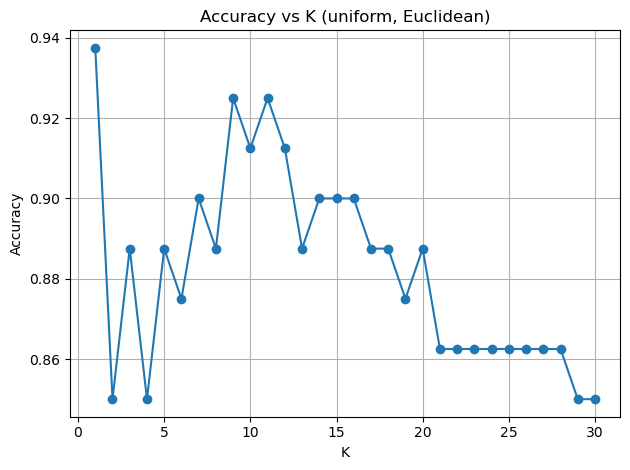

In [6]:
# 6) Simple K search without GridSearch (try K=1..30)
k_vals = list(range(1, 31))
scores = []
for k in k_vals:
    model = KNeighborsClassifier(n_neighbors=k, weights='uniform', p=2)
    model.fit(X_train_sc, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test_sc)))

best_k = k_vals[int(np.argmax(scores))]
best_acc = max(scores)
print(f'Best K on test set: {best_k} with accuracy {best_acc:.4f}')

plt.figure()
plt.plot(k_vals, scores, marker='o')
plt.title('Accuracy vs K (uniform, Euclidean)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()


In [7]:
# 7) Predict on new samples
new_X = np.array([
    [28, 38000, 25, 3],
    [45, 82000, 78, 12]
])
new_X_sc = scaler.transform(new_X)
pred_enc = knn.predict(new_X_sc)
pred_labels = le.inverse_transform(pred_enc)
list(pred_labels)

['Low-Value', 'High-Value']

### Tips
- Try `weights='distance'` for imbalanced/clustered data.
- Try `p=1` (Manhattan) vs `p=2` (Euclidean).
- Always scale features for distance-based methods.